# Procesamiento y Análisis de Datos EMG

Este cuaderno realiza el procesamiento de las sesiones almacenadas en `../storage/sessions`.
El flujo de trabajo incluye:
1. **Carga de Datos**: Lectura de archivos CSV.
2. **Limpieza**: 
    - Eliminación de bloques de tutorial ('Esferico' inicial).
    - Normalización de etiquetas (corrigiendo 'Esfi½rico' a 'Esférico').
    - Filtrado de registros con valores nulos (NaN).
    - Filtrado de registros con señales en 0.
3. **Análisis de Duración**: Estadísticas de la duración (número de muestras) de cada gesto.
4. **Análisis Exploratorio**: Conteo de registros totales por etiqueta.
5. **Normalización**: Escalado de las señales EMG.
6. **Exportación**: Generación de archivos CSV anonimizados por gesto.

In [70]:
!uv pip install pandas matplotlib

Using Python 3.11.2 environment at: C:\Users\kdfernan\Desktop\projects\practicas-comunitarias-PAOII\backend\.venv
Audited 2 packages in 6ms


In [71]:
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt

# Configuración de gráficos
plt.style.use('seaborn-v0_8-whitegrid')

In [72]:
# Ruta al directorio de sesiones
sessions_dir = os.path.join('..', 'storage', 'sessions')

csv_files = glob.glob(os.path.join(sessions_dir, '**', '*.csv'), recursive=True)
print(f"Se encontraron {len(csv_files)} archivos de sesión.")

Se encontraron 173 archivos de sesión.


## 1. Carga y Limpieza de Datos

En esta etapa cargamos los archivos y aplicamos los siguientes filtros:
- **Encoding**: Se usa `latin1` para soportar caracteres especiales.
- **Normalización de Nombres**: Se unifica `label` y `labels`.
- **Normalización de Etiquetas**: Se corrige la etiqueta 'Esferico' y sus variantes (como 'Esfi½rico') a 'Esférico'.
- **Tutorial**: Se elimina la primera aparición del gesto 'Esférico' de cada sesión (tutorial).
- **Exclusión Específica**: Se separan 'Diagnostics' en un DataFrame aparte (`excluded_df`).
- **Datos Nulos**: Se eliminan filas que contengan `NaN` en las columnas EMG.
- **Ceros**: Se eliminan filas donde alguna señal EMG sea exactamente 0 (indicador de desconexión o error).

In [73]:
dfs = []

for file in csv_files:
    try:
        # Encoding latin1 para tildes y eñes
        df = pd.read_csv(file, encoding='latin1')
        
        # Normalizar nombre de columna de etiqueta (algunos archivos usan 'labels' en plural)
        if 'labels' in df.columns:
            df.rename(columns={'labels': 'label'}, inplace=True)
        
        if not df.empty and 'label' in df.columns:
            # Detectar columnas EMG dinámicamente
            emg_cols = [c for c in df.columns if c.startswith('emg')]
            
            # --- FILTROS ---
            
            # 1. Eliminar filas con NaN en EMG
            df = df.dropna(subset=emg_cols)
            
            # Normalizar etiquetas 'Esferico' con errores de encoding (ej. Esfi½rico)
            if not df.empty:
                # Cualquier etiqueta que contenga 'Esf' se normaliza a 'Esférico'
                df.loc[df['label'].astype(str).str.contains('Esf', case=False, na=False), 'label'] = 'Esférico'
            
            # 2. Eliminar filas con Ceros en EMG (si alguna señal es 0)
            if emg_cols:
                # Mantiene filas donde NINGUNA columna EMG sea 0
                df = df[~(df[emg_cols] == 0).any(axis=1)]
            
            if df.empty:
                continue

            # 3. Eliminar el primer bloque 'Esferico' (tutorial)
            # Detectar cambios de etiqueta para identificar bloques
            df['block_id'] = (df['label'] != df['label'].shift()).cumsum()
            
            # Buscar bloques de 'Esférico' (ya normalizado)
            esferico_blocks = df[df['label'] == 'Esférico']['block_id'].unique()
            
            if len(esferico_blocks) > 0:
                first_esferico = esferico_blocks[0]
                df = df[df['block_id'] != first_esferico]
            
            # Limpiar auxiliar
            df = df.drop(columns=['block_id'])
            
            # Identificador de sesión
            df['source_file'] = os.path.basename(file)
            dfs.append(df)
            
    except Exception as e:
        print(f"Error leyendo {file}: {e}")

if dfs:
    all_data_df = pd.concat(dfs, ignore_index=True)
    
    # Separar gestos excluidos 'Diagnostics'
    # 'Esférico' se mantiene si es un gesto válido (post-tutorial)
    mask_excluded = all_data_df['label'].astype(str).str.contains('Diagnostics', case=False, regex=True)
    
    excluded_df = all_data_df[mask_excluded].copy()
    full_df = all_data_df[~mask_excluded].copy()
    
    print(f"Total de registros cargados: {len(all_data_df)}")
    print(f"Registros excluidos (Diagnostics): {len(excluded_df)}")
    print(f"Registros válidos para análisis: {len(full_df)}")
    
    if not excluded_df.empty:
        print("\nEjemplo de registros excluidos:")
        display(excluded_df.head())
    
    print("\nPrimeros registros válidos:")
    display(full_df.head())
else:
    full_df = pd.DataFrame()
    excluded_df = pd.DataFrame()

Error leyendo ..\storage\sessions\Andres Nenger\session_20260130_145026.csv: No columns to parse from file
Error leyendo ..\storage\sessions\Henry Arauz\session_20260204_154643.csv: No columns to parse from file
Error leyendo ..\storage\sessions\juanito\session_20260203_141532.csv: No columns to parse from file
Error leyendo ..\storage\sessions\kevin\session_20260130_155100.csv: No columns to parse from file
Error leyendo ..\storage\sessions\Michaell Toapanta\session_20260204_152117.csv: No columns to parse from file
Error leyendo ..\storage\sessions\Nager\session_20260205_100152.csv: No columns to parse from file
Error leyendo ..\storage\sessions\Nager\session_20260205_115730.csv: No columns to parse from file
Error leyendo ..\storage\sessions\Nager\session_20260205_115916.csv: No columns to parse from file
Total de registros cargados: 322333
Registros excluidos (Diagnostics): 3140
Registros válidos para análisis: 319193

Ejemplo de registros excluidos:


,nombre,edad,emg1,emg2,emg3,label,source_file
248302,Nager,26.0,2514.0,5037.0,2704.0,Diagnostics,session_20260205_095724.csv
248303,Nager,26.0,2514.0,5037.0,702.0,Diagnostics,session_20260205_095724.csv
248304,Nager,26.0,2514.0,5037.0,702.0,Diagnostics,session_20260205_095724.csv
248305,Nager,26.0,2514.0,5037.0,1460.0,Diagnostics,session_20260205_095724.csv
248306,Nager,26.0,2780.0,5037.0,1460.0,Diagnostics,session_20260205_095724.csv



Primeros registros válidos:


,nombre,edad,emg1,emg2,emg3,label,source_file
0,Adrian Mero,17.0,2574.0,3574.0,4504.0,Abrir,session_20260206_092855.csv
1,Adrian Mero,17.0,2574.0,3574.0,4504.0,Abrir,session_20260206_092855.csv
2,Adrian Mero,17.0,2574.0,3574.0,4504.0,Abrir,session_20260206_092855.csv
3,Adrian Mero,17.0,2574.0,3574.0,4504.0,Abrir,session_20260206_092855.csv
4,Adrian Mero,17.0,2574.0,3574.0,4504.0,Abrir,session_20260206_092855.csv


In [74]:
# Definir canales EMG finales
emg_channels = ['emg1', 'emg2', 'emg3']
available_channels = [c for c in emg_channels if c in full_df.columns]
print(f"Canales utilizados: {available_channels}")

Canales utilizados: ['emg1', 'emg2', 'emg3']


## 2. Análisis de Duración de Gestos
Aquí analizamos la consistencia de la recolección de datos.
Calculamos cuántas muestras tiene cada "instancia" de un gesto (desde que empieza hasta que termina).
- **Min**: Duración mínima registrada.
- **Max**: Duración máxima registrada.
- **Mean**: Duración promedio.

Estadísticas de Duración por Gesto:


,Gesto,Muestras Min,Muestras Max,Promedio Muestras,Cant. Instancias
0,Abrir,4,886,134.914773,176
1,Apuntar,1,1735,131.619883,171
2,Cerrar,1,247,123.854651,172
3,Cilindrico,2,4755,173.133721,172
4,Esférico,4,157,131.555556,153
5,Like,1,156,121.882353,170
6,Pinza,4,157,129.215116,172
7,Rest,1,2586,144.219800,1101


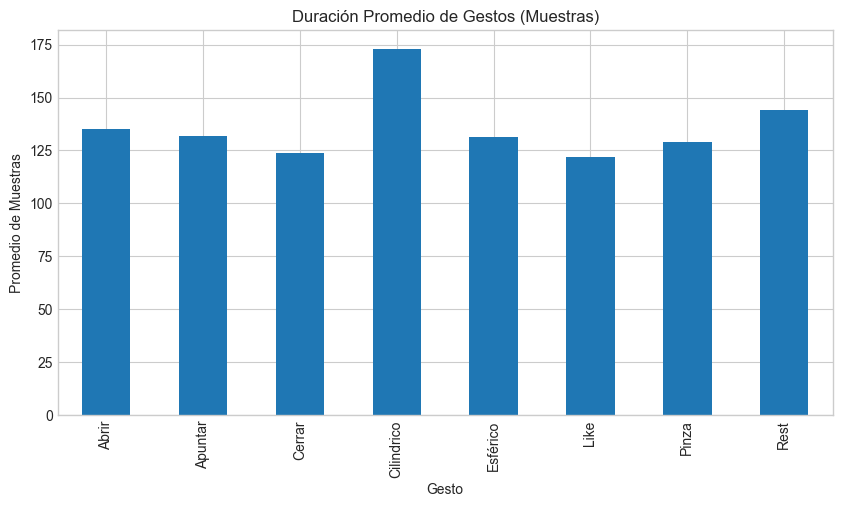

In [75]:
if not full_df.empty:
    # Recalcular bloques continuos globalmente (respetando separaciones de archivos)
    # Creamos un identificador único de bloque combinando source_file + cambio de label
    full_df['label_change'] = (full_df['labels'] if 'labels' in full_df.columns else full_df['label'] != (full_df['labels'] if 'labels' in full_df.columns else full_df['label']).shift()) | (full_df['source_file'] != full_df['source_file'].shift())
    full_df['global_block_id'] = full_df['label_change'].cumsum()
    
    # Contar muestras por bloque
    block_counts = full_df.groupby(['label', 'global_block_id']).size().reset_index(name='sample_count')
    
    # Calcular estadísticas por Gesto (Label)
    duration_stats = block_counts.groupby('label')['sample_count'].agg(['min', 'max', 'mean', 'count']).reset_index()
    duration_stats.columns = ['Gesto', 'Muestras Min', 'Muestras Max', 'Promedio Muestras', 'Cant. Instancias']
    
    print("Estadísticas de Duración por Gesto:")
    display(duration_stats)
    
    # Visualización de la duración promedio
    duration_stats.set_index('Gesto')['Promedio Muestras'].plot(kind='bar', figsize=(10, 5), title="Duración Promedio de Gestos (Muestras)")
    plt.ylabel("Promedio de Muestras")
    plt.show()

## 3. Conteo Total (GroupBy)
Cantidad total de muestras por etiqueta en todo el dataset.

,emg1,emg2,emg3
label,,,
Abrir,23745,23745,23745
Apuntar,22507,22507,22507
Cerrar,21303,21303,21303
Cilindrico,29779,29779,29779
Esférico,20128,20128,20128
Like,20720,20720,20720
Pinza,22225,22225,22225
Rest,158786,158786,158786


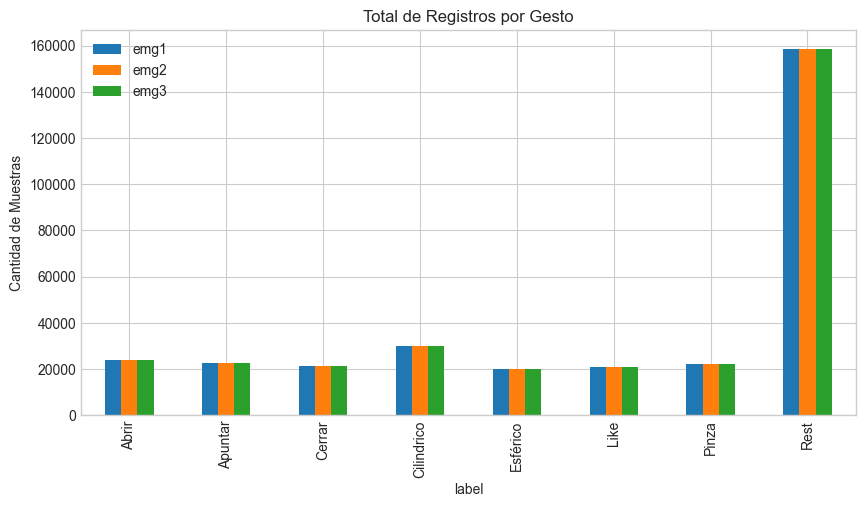

In [76]:
if not full_df.empty and 'label' in full_df.columns:
    grouped = full_df.groupby('label')[available_channels].count()
    display(grouped)
    
    # Gráfico de conteo
    grouped.plot(kind='bar', figsize=(10, 5), title="Total de Registros por Gesto")
    plt.ylabel("Cantidad de Muestras")
    plt.show()

## 4. Normalización de Señales
Normalización Min-Max por sesión. Se usa `transform` para mantener la estructura original del DataFrame.

In [77]:
# Crear copia para normalización
full_df_norm = full_df.copy()

if not full_df.empty:
    for channel in available_channels:
        # Función para escalar manejando división por cero
        def minmax_scale(x):
            denom = x.max() - x.min()
            if denom == 0:
                return pd.Series(0, index=x.index)
            return (x - x.min()) / denom
            
        # Transformar por grupo (sesión)
        full_df_norm[f'{channel}_norm'] = full_df.groupby('source_file')[channel].transform(minmax_scale)
    
    print("Normalización completada. Nuevas columnas generadas:")
    print([c for c in full_df_norm.columns if '_norm' in c])
    display(full_df_norm.head())

Normalización completada. Nuevas columnas generadas:
['emg1_norm', 'emg2_norm', 'emg3_norm']


,nombre,edad,emg1,emg2,emg3,label,source_file,label_change,global_block_id,emg1_norm,emg2_norm,emg3_norm
0,Adrian Mero,17.0,2574.0,3574.0,4504.0,Abrir,session_20260206_092855.csv,True,1,0.000046,0.00112,0.476972
1,Adrian Mero,17.0,2574.0,3574.0,4504.0,Abrir,session_20260206_092855.csv,False,1,0.000046,0.00112,0.476972
2,Adrian Mero,17.0,2574.0,3574.0,4504.0,Abrir,session_20260206_092855.csv,False,1,0.000046,0.00112,0.476972
3,Adrian Mero,17.0,2574.0,3574.0,4504.0,Abrir,session_20260206_092855.csv,False,1,0.000046,0.00112,0.476972
4,Adrian Mero,17.0,2574.0,3574.0,4504.0,Abrir,session_20260206_092855.csv,False,1,0.000046,0.00112,0.476972


## 5. Visualización: Original vs Normalizada

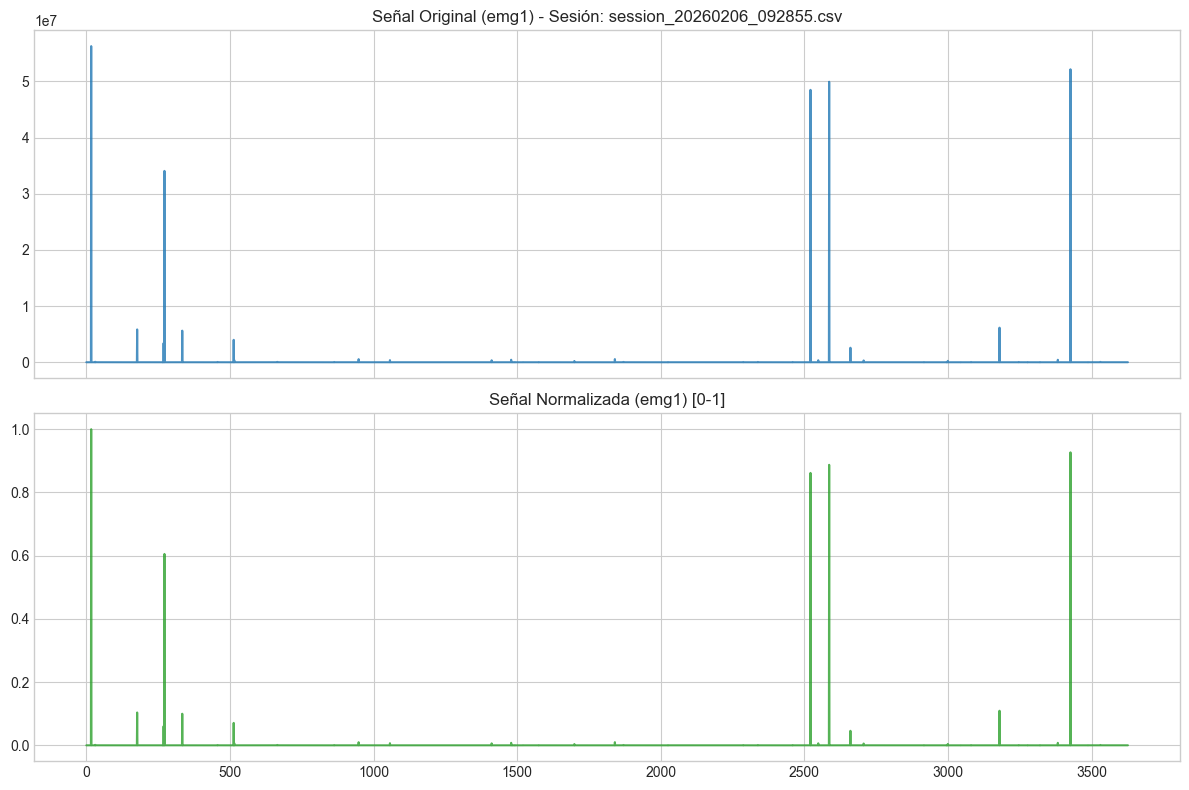

In [78]:
if not full_df_norm.empty:
    sample_session = full_df_norm['source_file'].unique()[0]
    subset = full_df_norm[full_df_norm['source_file'] == sample_session].reset_index(drop=True)
    
    channel_to_plot = available_channels[0]
    
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    
    axes[0].plot(subset[channel_to_plot], color='#1f77b4', alpha=0.8)
    axes[0].set_title(f"Señal Original ({channel_to_plot}) - Sesión: {sample_session}")
    
    axes[1].plot(subset[f'{channel_to_plot}_norm'], color='#2ca02c', alpha=0.8)
    axes[1].set_title(f"Señal Normalizada ({channel_to_plot}) [0-1]")
    
    plt.tight_layout()
    plt.show()

## 6. Exportación de Datos Anonimizados por Gesto
Se exportan únicamente las columnas EMG y timestamp, separadas por etiqueta en archivos CSV individuales.

In [79]:
if not full_df_norm.empty:
    # Directorio de salida
    output_dir = os.path.join(sessions_dir, '..', 'by_label')
    os.makedirs(output_dir, exist_ok=True)
    
    print(f"Exportando archivos a: {os.path.abspath(output_dir)}")
    
    # Asegurar que existe columna timestamp, si no la creamos (índice relativo)
    if 'timestamp' not in full_df_norm.columns:
        # Creamos un timestamp basado en el índice acumulado si no existe tiempo real
        full_df_norm = full_df_norm.reset_index(drop=True)
        full_df_norm['timestamp'] = full_df_norm.index
    
    # Definir columnas a exportar (Anonimización: Solo EMG y Timestamp)
    # Se usan las columnas originales de EMG (no las normalizadas, salvo que se requiera lo contrario)
    cols_to_export = ['timestamp'] + available_channels
    print(f"Columnas a exportar: {cols_to_export}")

    for label_name, group_data in full_df_norm.groupby('label'):
        # Limpiar nombre de archivo
        safe_label = str(label_name).strip().replace('/', '-').replace('\\', '-')
        csv_path = os.path.join(output_dir, f"{safe_label}.csv")
        
        # Guardar en CSV solo las columnas deseadas
        # Reiniciamos el índice del grupo para que el timestamp local sea relativo al archivo si se prefiere,
        # pero aquí mantenemos el timestamp global o generamos uno limpio.
        # Si se desea anonimizar totalmente, source_file, nombre y edad se omiten.
        
        export_data = group_data[cols_to_export].copy()
        
        export_data.to_csv(csv_path, index=False)
        print(f" - Guardado: {safe_label}.csv ({len(export_data)} registros)")
    
    print("\n¡Exportación completada!")

Exportando archivos a: c:\Users\kdfernan\Desktop\projects\practicas-comunitarias-PAOII\backend\storage\by_label
Columnas a exportar: ['timestamp', 'emg1', 'emg2', 'emg3']
 - Guardado: Abrir.csv (23745 registros)
 - Guardado: Apuntar.csv (22507 registros)
 - Guardado: Cerrar.csv (21303 registros)
 - Guardado: Cilindrico.csv (29779 registros)
 - Guardado: Esférico.csv (20128 registros)
 - Guardado: Like.csv (20720 registros)
 - Guardado: Pinza.csv (22225 registros)
 - Guardado: Rest.csv (158786 registros)

¡Exportación completada!
